# **Bayesian Inference on SIRD Models using MCMC:** Applied ML Exercise

## 1. Objective
This notebook applies **Bayesian inference** using **Markov Chain Monte Carlo (MCMC)** to estimate the **death rate (μ)** in extended versions of the **SIRD epidemiological model**. The goal is to explore how different model setups affect parameter estimation when observations are noisy.

## 2. Dataset
We generate **synthetic epidemic time series data** based on the **SIRD (Susceptible-Infected-Recovered-Deceased)** model. Controlled noise is added to simulate realistic measurement errors in each compartment.

## 3. Key Questions
1. Can Bayesian inference using MCMC accurately recover the true death rate from noisy SIRD data?
2. How does modeling assumptions—such as **mass conservation** or **independent noisy observations for all compartments**—influence the inference results?
3. What are the trade-offs between using a **3-state model** (with derived susceptible state) versus a **4-state model** (with all compartments treated as observed variables)?

## 4. Technical Highlights
- Implemented two versions of the **SIRD model**:
  - A **3-compartment model** where the **Susceptible (S)** state is derived from the other compartments.
  - A **4-compartment model** where **S, I, R, D** are all treated as independent noisy observations.
- Generated synthetic data using **log-normal noise** to simulate real-world data variability.
- Built and solved the **Bayesian models using PyMC** with **Differential Equation solvers**.
- Estimated the death rate parameter **μ** using **NUTS sampling**.
- Compared the posterior distributions, convergence behavior, and estimation accuracy between the two model approaches.
- All analysis was conducted using **Python (Jupyter Notebook)** with **PyMC, NumPy, and Matplotlib**.

# Part I. 3-State SIRD Model with Bayesian Inference for Death Rate $\mu$

- In this task, we extended the classic SIR epidemiological model to a **SIRD model** by explicitly introducing a fourth compartment: **Deaths ($D(t)$)**, governed by the death rate parameter $\mu$.
- We fixed:
1. The **recovery rate** $\gamma = 1.0$ </br>
2. The **infection rate** $\beta = 2.5$
3. Assume **mass conservation** - that the states of **$S(t) + I(t) + R(t) + D(t) = 1$.**

- We then:
4. **Generated synthetic data** using the SIRD model and a true death rate of $\mu_{\text{true}} = 0.3$
5. **Added log-normal noise** to simulate realistic, noisy observations for three compartments: $I(t), R(t), D(t)$. Note that $S(t)$ is not added with noisy observations yet because it is deterministically derived from the mass conservation constraint $S(t) = 1 - I(t) - R(t) - D(t)$, similar to the Professor's sample code. However, in this regard, $S(t)$ noise may not be log-normal and may be negative in some extreme case, due to its dependency with the other states.
6. Constructed a **Bayesian model using PyMC**, leveraging the `DifferentialEquation` wrapper to integrate the SIRD dynamics
7. Inferred the unknown parameter **$\mu$** from noisy data using **NUTS sampling**

In [1]:
# Import required libraries
import numpy as np                              
import matplotlib.pyplot as plt                 
import pymc as pm                               # PyMC for Bayesian modeling
from pymc.ode import DifferentialEquation       # For wrapping ODE systems in PyMC
from scipy.integrate import odeint              # For solving ODEs numerically
import arviz as az                              # For diagnostics and visualization of MCMC
import pandas as pd                             

In [2]:
# Parameters
np.random.seed(42)                              # Set random seed for reproducibility

beta = 2.5                                      # Infection rate (fixed)
gamma = 1.0                                     # Recovery rate (fixed)
mu_true = 0.3                                   # True death rate, used for generating synthetic data

# Initial population fractions: 99% susceptible, 1% infected, 0% recovered/dead
i0, r0, d0 = 0.01, 0.0, 0.0

f = 3.0                                         # Time scaling factor (to extend the total time window)
timestep = 0.5                                  # Step size for simulation time
times = np.arange(0, 5*f, timestep)             # Create time points from 0 to 15 with 0.5 increments

In [3]:
# SIRD ODE MODEL (for generating true data)
def SIRD_3st(y, t, p):
    i, r, d = y                              # Unpack state variables
    mu = p[0]                                # Death rate (parameter to infer later)
    s=1-r-d-i
    return [
        beta * s * i - gamma * i - mu * i,      # dI/dt = βSI - γI - μI
        gamma * i,                              # dR/dt = γI
        mu * i                                  # dD/dt = μI
    ]

In [4]:
# Generate synthetic data with noise
y_clean = odeint(SIRD_3st, t=times, y0=[i0, r0, d0], args=([mu_true],), rtol=1e-8) # Simulate the true trajectory with known mu

sigma_vals = np.array([0.4, 0.2, 0.3])     # Assumed log-normal noise levels for  I, R, D
yobs = np.random.lognormal(mean=np.log(y_clean[1:]), sigma=sigma_vals)

In [5]:
# Symbolic-compatible ODE (for PyMC model)
def SIRD_3states(y, t, p):
    i = y[0]
    r = y[1]
    d = y[2]
    mu = p[0]
    s= 1-i-r-d
    di = beta * s * i - gamma * i - mu * i
    dr = gamma * i
    dd = mu * i
    return [di, dr, dd] 

In [6]:
# ODE container for PyMC
sird_model_3states = DifferentialEquation(
    func=SIRD_3states,                                 
    times=times[1:],                           
    n_states=3,                                # Number of ODE states (I, R, D)
    n_theta=1,                                 # Only one parameter to infer: mu
    t0=0                                       
)

In [ ]:
# PyMC MODEL
with pm.Model() as model:
    sigma_3states = pm.HalfNormal("sigma", sigma=0.5, shape=3)     # Prior for noise levels (1 per variable:  I, R, D)
    mu_3states = pm.Uniform("mu", lower=0.01, upper=1.0)           # Prior for death rate mu (to be inferred)
    
    sird_curves_3states = sird_model_3states(y0=[i0, r0, d0], theta=[mu_3states])
    Y_3states = pm.Lognormal("Y", mu=pm.math.log(sird_curves_3states), sigma=sigma_3states, observed=yobs)
    trace_3states = pm.sample(400, tune=500, target_accept=0.9, chains=4 ,cores=4, random_seed=123, progressbar=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, mu]


/opt/anaconda3/envs/mads-env/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 500 tune and 400 draw iterations (2_000 + 1_600 draws total) took 181 seconds.


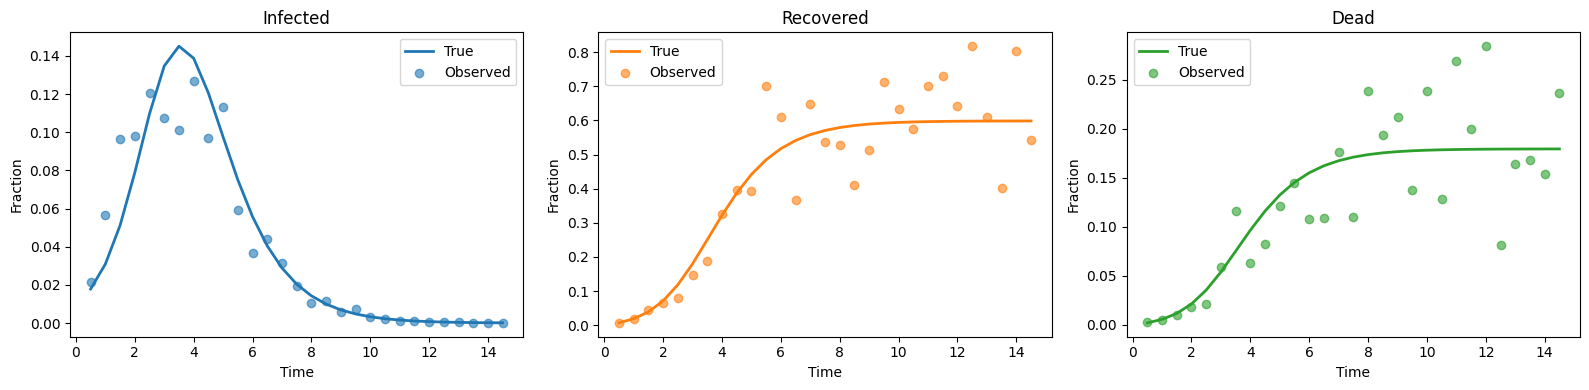

In [ ]:
# Plotting
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
labels = ['Infected', 'Recovered', 'Dead']     # No Susceptible observations yet as it is dependent on I, R, D states
colors = ['C0', 'C1', 'C2']                    # Susceptible may not have positive and log-normal noise in this case

# Plot true trajectory vs noisy observations
for i, ax in enumerate(axs.flatten()):
    ax.plot(times[1:], y_clean[1:, i], label='True', color=colors[i], linewidth=2)
    ax.scatter(times[1:], yobs[:, i], label='Observed', color=colors[i], alpha=0.6)
    ax.set_title(labels[i])
    ax.set_xlabel("Time")
    ax.set_ylabel("Fraction")
    ax.legend()

plt.tight_layout()

In [ ]:
# Summary and diagnostics
summary_df_3states = az.summary(trace_3states, var_names=["mu", "sigma"], hdi_prob=0.95).round(3)
summary_df_3states.reset_index(inplace=True)
print(summary_df_3states)


      index   mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
0        mu  0.295  0.020     0.256      0.332      0.000    0.000    1692.0   
1  sigma[0]  0.289  0.039     0.218      0.366      0.001    0.001    1659.0   
2  sigma[1]  0.222  0.032     0.162      0.284      0.001    0.001    1522.0   
3  sigma[2]  0.327  0.047     0.236      0.415      0.001    0.002    1537.0   

   ess_tail  r_hat  
0    1273.0    1.0  
1    1409.0    1.0  
2     855.0    1.0  
3    1064.0    1.0  


<Axes: title={'center': 'mu'}>

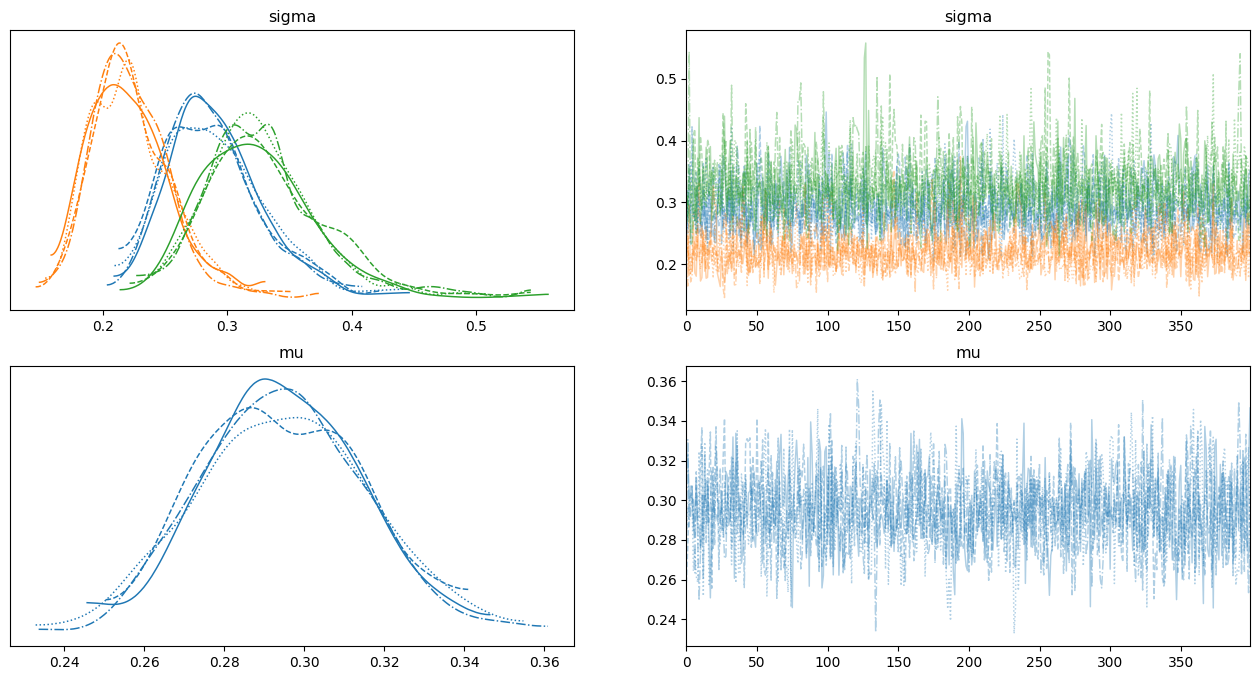

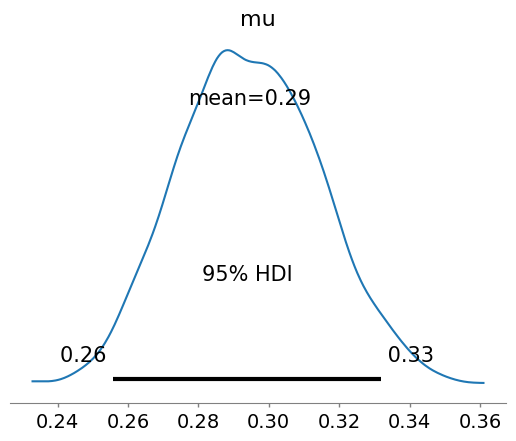

In [10]:
az.plot_trace(trace_3states,figsize=(16, 8))
az.plot_posterior(trace_3states, var_names=["mu"], hdi_prob=0.95)

## Key Findings for Part I:

- The posterior distribution for $\mu$ was centered around **0.295**, very close to the true value of **0.3**
- The **95% Highest Density Interval (HDI)** for $\mu$ ranged from approximately **0.256 to 0.332**, confirming accurate inference
- Visual diagnostics showed **fairly good model fit** to the true dynamics for 3 compartments, especially $I(t)$ and $R(t)$.


-------------------
# Part II. 4-State SIRD Model with Bayesian Inference for Death Rate $\mu$

- Here, we try another approach using 4-compartment models, treating all compartments as independent state variables, including Susceptible $S(t)$, which is no longer derived from the others.

- We assume that: 
1. Each of the compartments — Susceptible, Infected, Recovered, Deceased — is treated as an **independent time series**.
2. Unlike the previous approach, $S(t)$ can have a noisy observation, specifically **a log-normal and non-negative noise for S**, as stated in the assignment instructions. 
3. Thus, **mass conservation may not hold exactly true ($S(t) + I(t) + R(t) + D(t) ≠ 1$)** due to independent noise of $S(t)$.


In [ ]:
# Parameters
np.random.seed(42)                              

beta = 2.5                                     
gamma = 1.0                                    
mu_true = 0.3                                   

# Initial population fractions: 99% susceptible, 1% infected, 0% recovered/dead
s0, i0, r0, d0 = 0.99, 0.01, 0.0, 0.0

f = 3.0                                         
timestep = 0.5                                  
times = np.arange(0, 5*f, timestep)             

In [12]:
# SIRD ODE MODEL (for generating true data)
def SIRD_4st(y, t, p):
    s, i, r, d = y                              
    mu = p[0]                                   # Death rate (parameter to infer later)
    return [
        -beta * s * i,                          # dS/dt = -βSI, where S(t) is now independent
        beta * s * i - gamma * i - mu * i,      # dI/dt = βSI - γI - μI
        gamma * i,                              # dR/dt = γI
        mu * i                                  # dD/dt = μI
    ]

In [13]:
# Generate synthetic data with noise
y_clean = odeint(SIRD_4st, t=times, y0=[s0, i0, r0, d0], args=([mu_true],), rtol=1e-8) 

sigma_vals = np.array([0.2, 0.3, 0.3, 0.2])      # Assumed log-normal noise levels for S, I, R, D
yobs = np.random.lognormal(mean=np.log(y_clean[1:]), sigma=sigma_vals) 

In [14]:
# Symbolic-compatible ODE (for PyMC model)
def SIRD_4states(y, t, p):
    s = y[0]
    i = y[1]
    r = y[2]
    d = y[3]
    mu = p[0]
    ds = -beta * s * i
    di = beta * s * i - gamma * i - mu * i
    dr = gamma * i
    dd = mu * i
    return [ds, di, dr, dd] 

In [15]:
# ODE container for PyMC
sird_model_4states = DifferentialEquation(
    func=SIRD_4states,                                
    times=times[1:],                           
    n_states=4,                 # Number of ODE states (S, I, R, D)
    n_theta=1,                                 
    t0=0                                       
)

In [16]:
# PyMC MODEL
with pm.Model() as model:
    sigma_4states = pm.HalfNormal("sigma", sigma=0.5, shape=4)    # Prior for noise levels (1 per variable: S, I, R, D)
    mu_4states = pm.Uniform("mu", lower=0.01, upper=1.0)          # Prior for death rate mu (to be inferred)

    sird_curves_4states = sird_model_4states(y0=[s0, i0, r0, d0], theta=[mu_4states])
    Y_4states = pm.Lognormal("Y", mu=pm.math.log(sird_curves_4states), sigma=sigma_4states, observed=yobs)
    trace_4states = pm.sample(1000, tune=1000, target_accept=0.9, cores=1, random_seed=123, progressbar=False)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 380 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


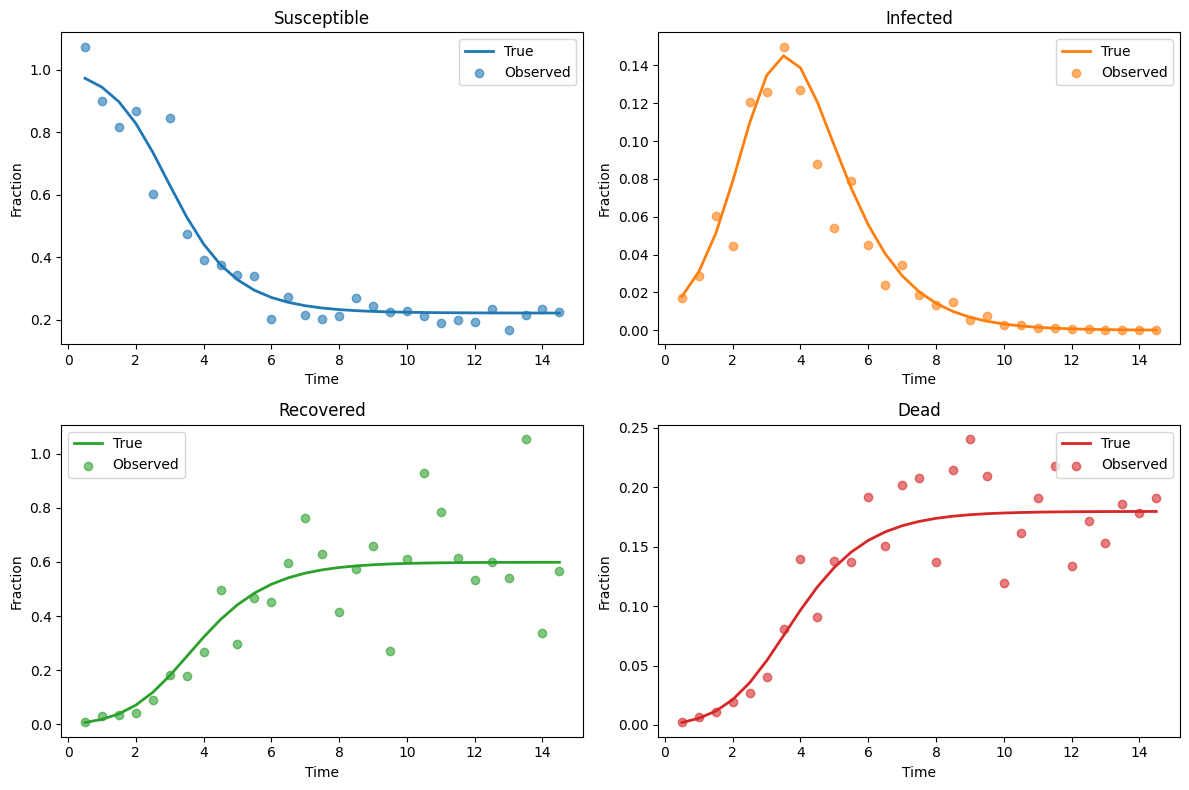

In [17]:
# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
labels = ['Susceptible', 'Infected', 'Recovered', 'Dead']
colors = ['C0', 'C1', 'C2', 'C3']

# Plot true trajectory vs noisy observations
for i, ax in enumerate(axs.flatten()):
    ax.plot(times[1:], y_clean[1:, i], label='True', color=colors[i], linewidth=2)
    ax.scatter(times[1:], yobs[:, i], label='Observed', color=colors[i], alpha=0.6)
    ax.set_title(labels[i])
    ax.set_xlabel("Time")
    ax.set_ylabel("Fraction")
    ax.legend()

plt.tight_layout()

In [18]:
# Summary and diagnostics
summary_df_4states = az.summary(trace_4states, var_names=["mu", "sigma"], hdi_prob=0.95).round(3)
summary_df_4states.reset_index(inplace=True)
print(summary_df_4states)

      index   mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
0        mu  0.298  0.012     0.273      0.320      0.000    0.000    2444.0   
1  sigma[0]  0.141  0.021     0.102      0.179      0.001    0.001    2039.0   
2  sigma[1]  0.292  0.039     0.228      0.377      0.001    0.001    2764.0   
3  sigma[2]  0.324  0.045     0.240      0.412      0.001    0.001    2544.0   
4  sigma[3]  0.212  0.030     0.157      0.269      0.001    0.001    2432.0   

   ess_tail  r_hat  
0    1202.0    1.0  
1    1229.0    1.0  
2    1520.0    1.0  
3    1446.0    1.0  
4    1272.0    1.0  


<Axes: title={'center': 'mu'}>

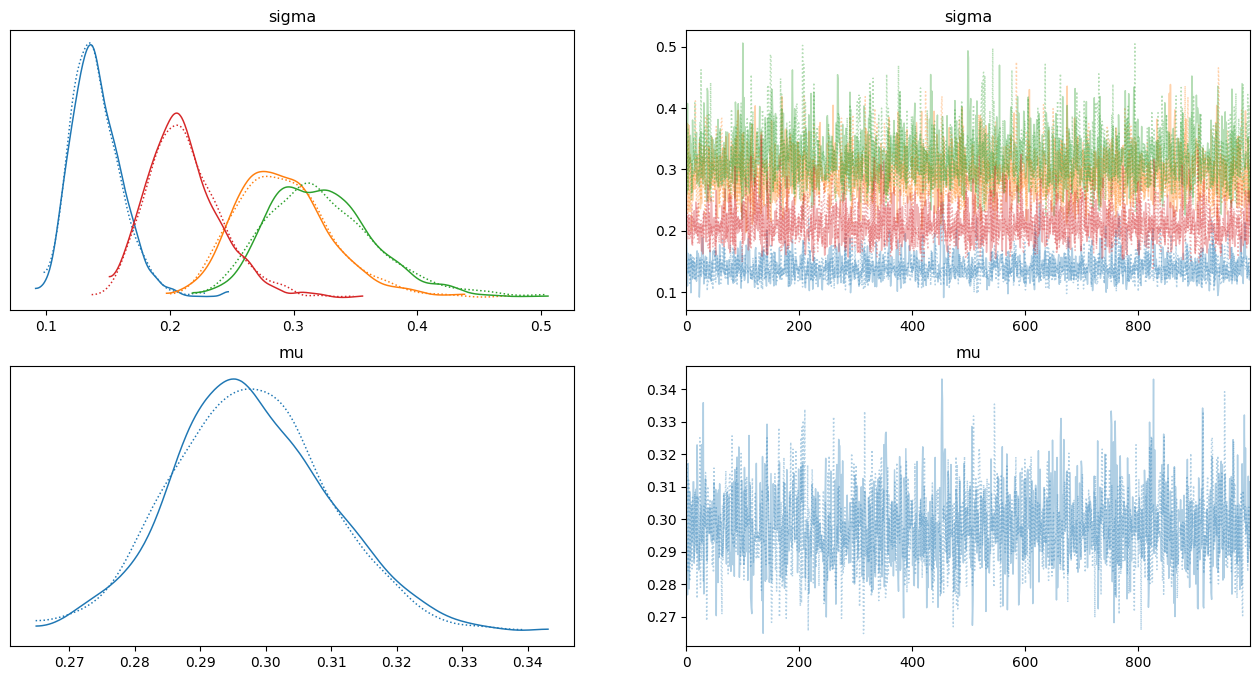

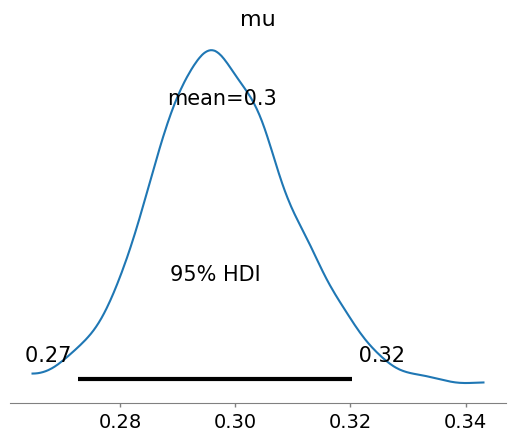

In [19]:
az.plot_trace(trace_4states,figsize=(16, 8))
az.plot_posterior(trace_4states, var_names=["mu"], hdi_prob=0.95)

## Key Findings for Part II:
- The posterior for the death rate $\mu$ converged near 0.298, closely matching the true value of 0.300.
- The 95% highest density interval (HDI) ranged approximately from 0.273 to 0.320, indicating high confidence and precision in the estimate.

## Takeaways for Parts I and II:
- The above results demonstrate that:
1. **Bayesian SIRD works**: Even with noisy synthetic data, MCMC in PyMC can recover underlying rates very reliably.
2. **Both 3- and 4-state setups estimate μ well**: However, allowing all four compartments to float independently (the 4-state model) produces a sharper estimate in our experiment, likely due to the richer information content from directly observing all compartments.

### 3-State SIRD (I, R, D) with Derived Susceptible Compartment:
- Pros:
1. **Closed population assumption**: Using the 3-State Model assures mass conservation ($S(t) + I(t) + R(t) + D(t) = 1$), or when the population of the dataset is fixed.
2. **Lower computational cost**: Also, because of we have lesser features/dimensions to infer, the 3-State Model is more computationally efficient.
3. **Robust latent recovery**: Even with noisy data for 3 states, Bayesian methods like PyMC can fairly recover latent parameters like death rate $\mu$. 

- Cons:
1. **Noisy S(t) estimation**: Susceptible compartment is derived, not observed, so noise can propagate in unrealistic ways (e.g., negative values, non-log-normal behavior).
2. **Rigid conservation constraint**: Mass conservation may not hold in real-world data due to underreporting or lags in data, potentially biasing inference to the model. 

### 4-State SIRD (S, I, R, D) with Fully Noisy Observation Models:
- Pros:
1. **Improved parameter accuracy**: Observing all 4 compartments ($S$, $I$, $R$, $D$) yielded to a $\mu$ (0.298) that is closer to the true value of 0.300. 
2. **Better data fidelity**: Each compartment can be modeled with its own noise distribution, improving fit to real-world observational variability.
3. **Supports open populations**: This model is useful in scenarios with non-constant populations (e.g. immigration, births), or when total population is not precisely known.
4. **Handles measurement asymmetry**: Having 4 states in the model allows modeling of differential uncertainty across compartments (e.g., death data may be more reliable than infection counts.)

- Cons:
1. **Loss of mass conservation**: There is no inherent guarantee that $S(t) + I(t) + R(t) + D(t) = N$, which may yield inconsistent results. This can lead to unphysical states, especially when noise in observed data is high or uneven across compartments.
2. **Increased model complexity**: More ODEs, noise terms, and parameters (higher dimensionality) increase computational demands and slow convergence.
3. **Sensitivity to inconsistencies**: When each compartment is observed independently with noise, small mismatches between compartments (e.g., recovery faster than infection decline) may destabilize the model or lead to overfitting noise.

-------------------
# Part III. Reduced-Data Inference: Can We Estimate $\mu$ from Only $I(t)$ and $D(t)$?

- To test the robustness of the inference process, we removed $S(t)$ and $R(t)$ from the observed data and re-estimated the death rate $\mu$ using only noisy measurements of:

1. $I(t)$ (Infected)
2. $D(t)$ (Dead)

- Here, we are using the **3-States Model** to derive the mean from Infected and Dead observations, given that it is more computationally efficient. 


In [ ]:
# Optional: Inference using only I(t) and D(t)
# Slice only I(t) and D(t) from both noisy observations and model output
yobs_reduced = yobs[:, [0, 2]]             # Noisy observations for I and D only
observed_vars = [0, 2]                     # Indices of I and D

# Adjust the symbolic ODE wrapper to return full system
sird_model_reduced = DifferentialEquation(
    func=SIRD_3states,
    times=times[1:],
    n_states=3,
    n_theta=1,
    t0=0
)

In [ ]:
# Rebuild a new PyMC model using only I and D
with pm.Model() as reduced_model:
    sigma_reduced = pm.HalfNormal("sigma_reduced", sigma=0.5, shape=2)
    mu_reduced = pm.Uniform("mu_reduced", lower=0.01, upper=1.0)

    # Get full curve predictions
    sird_curves_full = sird_model_reduced(y0=[i0, r0, d0], theta=[mu_reduced])

    # Extract only I and D predictions from model output
    sird_curves_reduced = sird_curves_full[:, observed_vars]

    # Define likelihood only for I(t), D(t)
    Y_reduced = pm.Lognormal("Y_reduced", mu=pm.math.log(sird_curves_reduced),
                             sigma=sigma_reduced, observed=yobs_reduced)

    trace_reduced = pm.sample(400, tune=500, target_accept=0.9, chains=4,cores=4, random_seed=456)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_reduced, mu_reduced]


/opt/anaconda3/envs/mads-env/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 500 tune and 400 draw iterations (2_000 + 1_600 draws total) took 80 seconds.


                   mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
mu_reduced        0.280  0.024     0.236      0.325      0.001    0.001   
sigma_reduced[0]  0.290  0.041     0.214      0.366      0.001    0.001   
sigma_reduced[1]  0.326  0.046     0.240      0.414      0.001    0.001   

                  ess_bulk  ess_tail  r_hat  
mu_reduced          1324.0    1066.0    1.0  
sigma_reduced[0]    1815.0    1140.0    1.0  
sigma_reduced[1]    1118.0    1180.0    1.0  


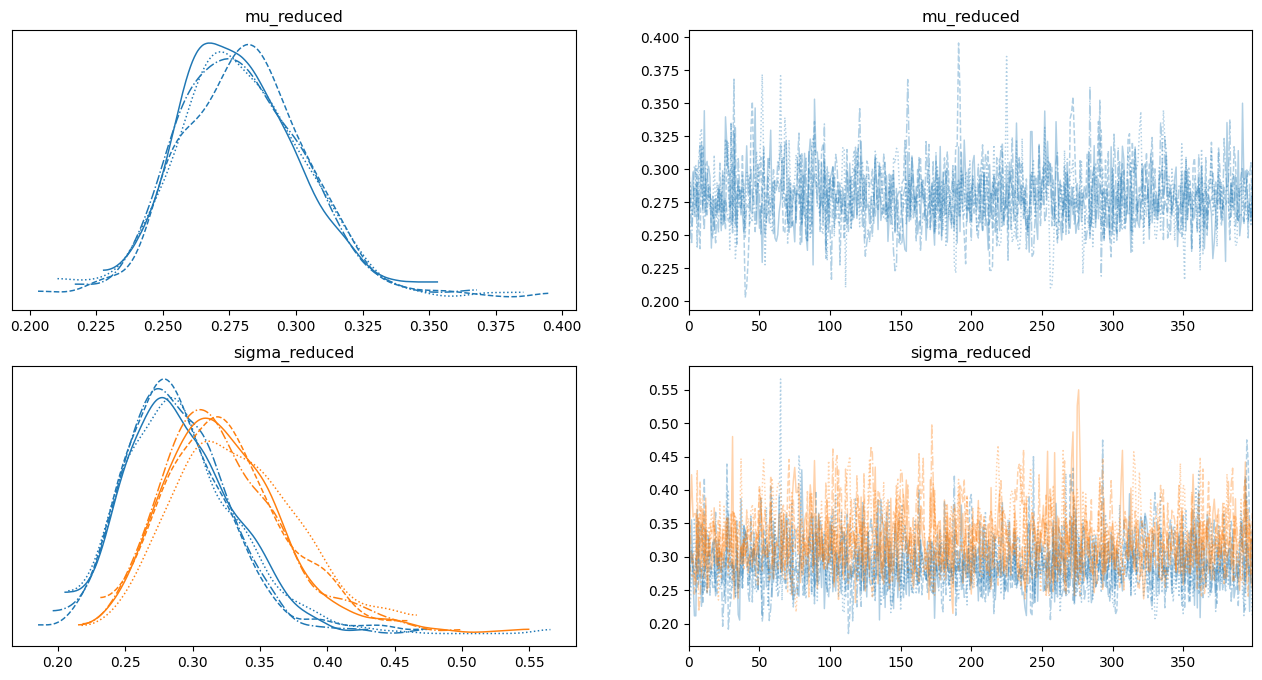

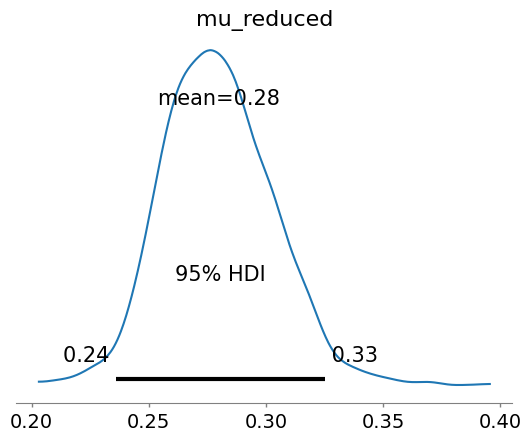

In [13]:
# Evaluation: Posterior of μ with limited data
az.plot_trace(trace_reduced, var_names=["mu_reduced", "sigma_reduced"], figsize=(16, 8))
az.plot_posterior(trace_reduced, var_names=["mu_reduced"], hdi_prob=0.95)

# Summary table
summary_reduced = az.summary(trace_reduced, var_names=["mu_reduced", "sigma_reduced"], hdi_prob=0.95).round(3)
print(summary_reduced)

## Inference Results:
- **Posterior mean of $\mu$:** 0.280  
- **95% Highest Density Interval (HDI):** [0.236, 0.325]  
- **True $\mu$: 0.3** (still contained within HDI)

Despite missing half of the compartments, the model still produced a **reasonable posterior** for $\mu$, centered slightly lower but with manageable uncertainty.

## Interpretation:
- The model compensates well by relying on the fact that **$D'(t) = \mu \cdot I(t)$**.
- Since both $I$ and $D$ are **directly influenced by $\mu$**, their combination still provides strong identifiability.
- As expected, the posterior **mean shifted further from ground truth and HDI widened** compared to the full-data case.

## Conclusion:
Inference of the death rate $\mu$ remains **feasible and informative** even without observing $R$.
